In [7]:
## Model evaluation — test-set profit comparison

Load coordinated RL, myopic, and single-market rolling-intrinsic **daily** `profit.csv` files and merge on **delivery calendar day** (Europe/Berlin). The RL file defines which days are in scope.

**Choose the RL run** with `SELECTED_MODEL` (folder `output/coordinated_multi_market/logging/<id>/`). Training ranges for each id are in `evaluation/rl_model_registry.py`.

Run from the **repository root** or from `evaluation/` (paths adjusted in the next cell).

In [13]:
# --- only switch you need for coordinated RL outputs ---
SELECTED_MODEL = "1"  # "0" … "5"; see evaluation.rl_model_registry.RL_MODEL_REGISTRY

from pathlib import Path
import sys

_root = Path.cwd().resolve()
if _root.name == "evaluation":
    sys.path.insert(0, str(_root.parent))
else:
    sys.path.insert(0, str(_root))

import pandas as pd

from evaluation.merge_test_profits import build_test_comparison_df, default_paths_bs15
from evaluation.rl_model_registry import get_rl_model_spec, registry_as_dataframe

spec = get_rl_model_spec(SELECTED_MODEL)
print(spec.model_number, spec.describe_training())

paths = default_paths_bs15(SELECTED_MODEL)
from IPython.display import display

display(registry_as_dataframe())
paths

1 01.01.2019–31.03.2021 (Europe/Berlin)


,model_number,train_start,train_end_inclusive,train_end_exclusive,tensorboard_run_subdir
0,0,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_0_1
1,1,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_1_0
2,2,2023-01-01 00:00:00+01:00,2025-03-01 00:00:00+01:00,2025-03-02 00:00:00+01:00,PPO_2_1
3,3,2023-01-01 00:00:00+01:00,2025-03-01 00:00:00+01:00,2025-03-02 00:00:00+01:00,PPO_3_0
4,4,2019-01-01 00:00:00+01:00,2024-09-30 00:00:00+02:00,2024-10-01 00:00:00+02:00,PPO_4_1
5,5,2019-01-01 00:00:00+01:00,2024-09-30 00:00:00+02:00,2024-10-01 00:00:00+02:00,PPO_5_0


{'model_number': '1',
 'train_start': '2019-01-01T00:00:00+01:00',
 'train_end_inclusive': '2021-03-31T00:00:00+02:00',
 'rl': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/coordinated_multi_market/logging/1/rolling_intrinsic_intelligently_stacked_on_day_ahead_qh/bs15cr1rto0.86mc365mt10/profit.csv',
 'myopic': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/myopic_multi_market/rolling_intrinsic_stacked_on_day_ahead_qh/bs15cr1rto0.86mc365mt10/profit.csv',
 'single_glob': 'output/single_market/rolling_intrinsic/ri_basic/qh/*/bs15cr1rto0.86mc365mt10/profit.csv',
 'single_file': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv'}

In [14]:
# Prefer glob: single-market RI is often stored per calendar year under qh/<year>/...
try:
    df_test = build_test_comparison_df(
        paths["rl"],
        paths["myopic"],
        single_market_glob=paths["single_glob"],
    )
except FileNotFoundError:
    df_test = build_test_comparison_df(
        paths["rl"],
        paths["myopic"],
        single_market_profit_csv=paths["single_file"],
    )

df_test.head(10)

,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,77.717315,92.200414,94.756532
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,166.266625,171.773142,170.710072
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,109.548671,108.628091,101.722099
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,154.540957,135.974138,146.519762
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,232.071455,246.913258,270.850620
5,2021-04-06 00:00:00+02:00,2021-04-06 00:00:00+02:00,267.898332,277.790859,260.867058
6,2021-04-07 00:00:00+02:00,2021-04-07 00:00:00+02:00,136.549838,137.939105,130.341463
7,2021-04-08 00:00:00+02:00,2021-04-08 00:00:00+02:00,127.221737,122.879300,150.934430
8,2021-04-09 00:00:00+02:00,2021-04-09 00:00:00+02:00,100.768890,94.549413,94.911422
9,2021-04-10 00:00:00+02:00,2021-04-10 00:00:00+02:00,121.707625,128.785421,136.493605


In [15]:
# Coverage check: baselines should have rows for each RL test day
summary = pd.DataFrame(
    {
        "rows": [len(df_test)],
        "myopic_missing": [df_test["profit_myopic"].isna().sum()],
        "single_market_missing": [df_test["profit_single_market_ri"].isna().sum()],
    }
)
summary

,rows,myopic_missing,single_market_missing
0,183,0,0


### Brute-force upper bound (per-day `summary_*.csv`)

For each test `delivery_day`, load `coordinated_market_upper_bound_analysis/results_merged/summary_YYYY-MM-DD.csv` and add **max / median / q75 / q90** of the `profit` column across all scenarios in that file.

For many repeated analyses you can later run `build_brute_force_long_cache()` once (see `evaluation/brute_force_summary_stats.py`).

In [16]:
from evaluation.brute_force_summary_stats import attach_brute_force_stats, default_results_merged_dir

df_test_bf = attach_brute_force_stats(df_test, on_missing="warn")
df_test_bf.head()

,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,77.717315,92.200414,94.756532,117.956864,99.411648,107.720561,111.324238
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,166.266625,171.773142,170.710072,192.907218,163.094569,174.238685,179.897878
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,109.548671,108.628091,101.722099,115.858681,102.531147,106.572748,110.101994
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,154.540957,135.974138,146.519762,176.436141,143.379189,151.560586,160.445248
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,232.071455,246.913258,270.850620,339.618408,278.331090,293.804740,311.066889


In [17]:
df_test.describe()

,profit_rl_coordinated,profit_myopic,profit_single_market_ri
count,183.000000,183.000000,183.000000
mean,144.810344,140.191729,142.493344
std,67.277265,65.891204,62.641105
min,53.778721,54.627816,61.393795
25%,98.681207,92.254630,94.853304
50%,124.866627,120.253871,126.098533
75%,173.092696,165.646434,171.215533
max,387.423524,370.463733,349.226962


### Cumulative profit + SoC (coordinated RL, test days)

**Left:** stacked **cumulative** profit (€): day-ahead trades (`execution_time` hour == 13 Berlin) vs intraday, summed from each row’s `profit` in `trades/trades_YYYY-MM-DD.csv` (same colour/hatch idea as your thesis reference: teal DA, pink IDC).

**Right:** mean **DA** vs **actual** SoC bands (96×15 min delivery time), as before.

Set **`SOC_Q_LOW`** / **`SOC_Q_HIGH`** in the code cell; implementation: `evaluation.coordinated_rl_test_plots`.


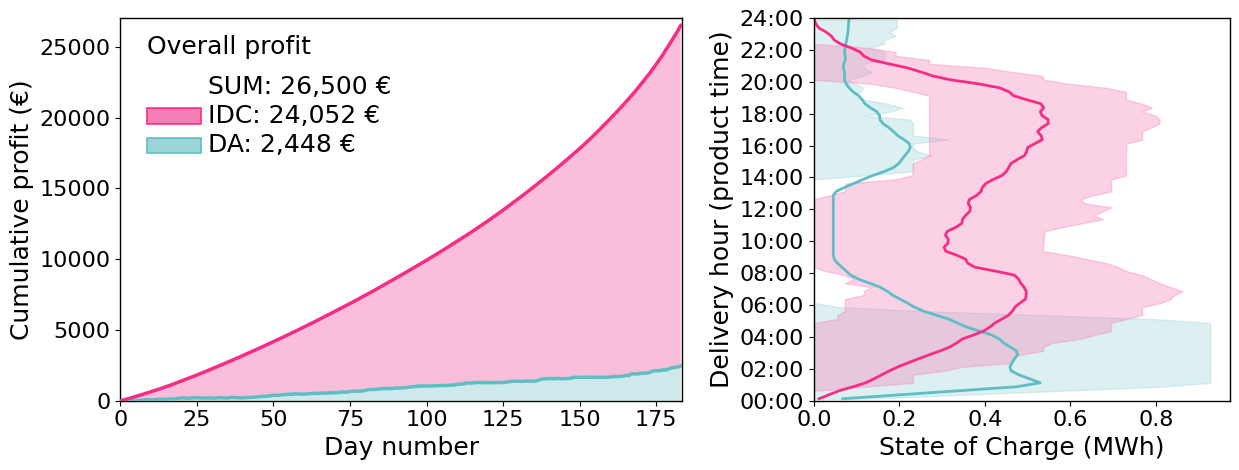

In [18]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import coordinated_rl_cumulative_profit_and_soc_figure

# --- SoC band quantiles (change here; legend text updates automatically) ---
SOC_Q_LOW = 0.25
SOC_Q_HIGH = 0.75
assert 0.0 <= SOC_Q_LOW < SOC_Q_HIGH <= 1.0

fig, ax_cum, ax_soc, profit_tbl, mat_da, mat_all, s_da, s_all = (
    coordinated_rl_cumulative_profit_and_soc_figure(
        SELECTED_MODEL,
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
    )
)
plt.show()

### Cumulative profit + SoC (myopic multi-market, test days)

Same layout as coordinated RL: **left** = stacked cumulative DA vs intraday € from `output/myopic_multi_market/rolling_intrinsic_stacked_on_day_ahead_qh/<bs>/trades/`; **right** = mean DA vs actual SoC (swapped axes, no legend). Reuses **`SOC_Q_LOW`** / **`SOC_Q_HIGH`** from the cell above. Implementation: `evaluation.coordinated_rl_test_plots.myopic_cumulative_profit_and_soc_figure`.

In [ ]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import myopic_cumulative_profit_and_soc_figure

fig_m, ax_cum_m, ax_soc_m, profit_tbl_m, mat_da_m, mat_all_m, s_da_m, s_all_m = (
    myopic_cumulative_profit_and_soc_figure(
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
    )
)
plt.show()

### SoC — myopic multi-market

Same as coordinated RL: **DA** (execution hour 13 Berlin) vs **actual** (all trades). Trades folder: `output/myopic_multi_market/.../trades/`.

Uses **`SOC_Q_LOW` / `SOC_Q_HIGH`** from the coordinated RL cell above (re-run that cell first if you change them).

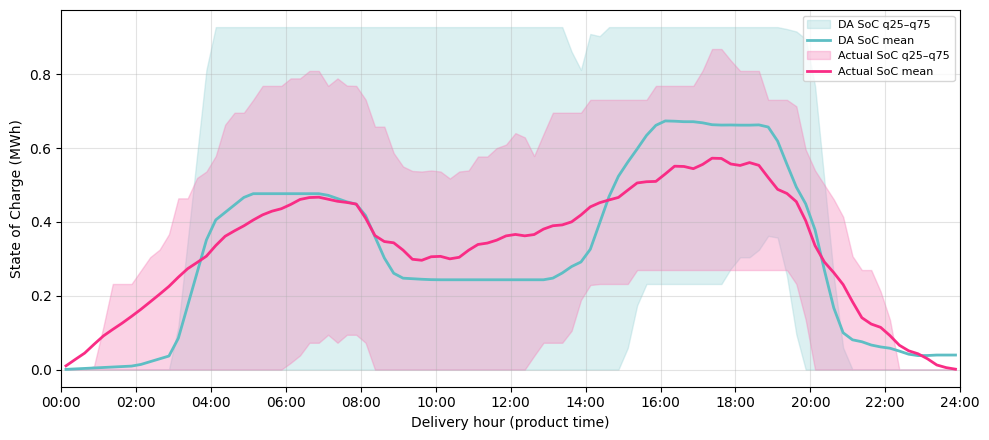

In [19]:
import matplotlib.pyplot as plt
from evaluation.soc_profiles import myopic_soc_plot_from_test_days

fig_m, ax_m, mat_da_m, mat_all_m, s_da_m, s_all_m = myopic_soc_plot_from_test_days(
    df_test["delivery_day"],
    e_max_mwh=1.0,
    soc0_mwh=0.0,
    q_low=SOC_Q_LOW,
    q_high=SOC_Q_HIGH,
)
fig_m.tight_layout()
plt.show()

### SoC — single-market rolling intrinsic

**No day-ahead trades** in this pipeline: only one band + mean (**all trades** / intraday). Trade files live under `output/single_market/.../qh/<year>/.../trades/`; the resolver picks the year folder that contains `trades_YYYY-MM-DD.csv`.

Uses **`SOC_Q_LOW` / `SOC_Q_HIGH`** from the coordinated RL cell.

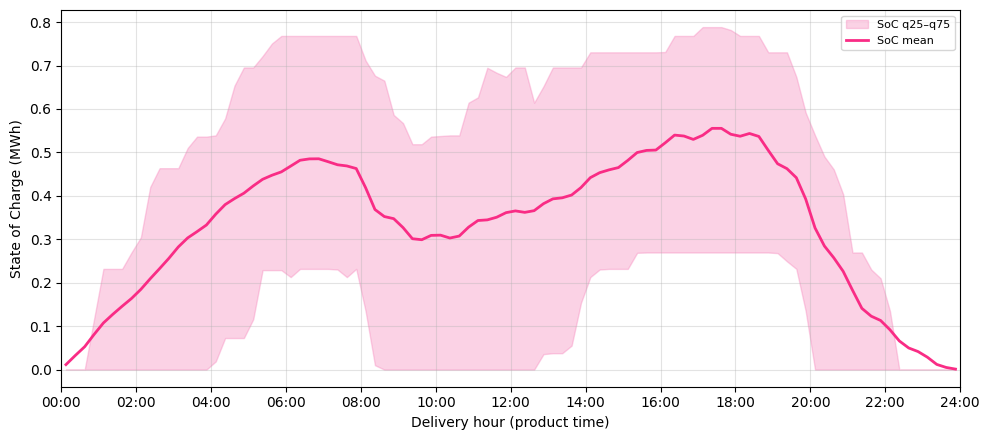

In [20]:
import matplotlib.pyplot as plt
from evaluation.soc_profiles import single_market_soc_plot_from_test_days

fig_s, ax_s, mat_all_s, s_all_s = single_market_soc_plot_from_test_days(
    df_test["delivery_day"],
    e_max_mwh=1.0,
    soc0_mwh=0.0,
    q_low=SOC_Q_LOW,
    q_high=SOC_Q_HIGH,
)
fig_s.tight_layout()
plt.show()

### Training vs validation profit (side by side)

**Left — TensorBoard (training):** mean **combined € profit** from `episode_profit/combined_eur` vs **environment timestep** (`output/coordinated_multi_market/tensorboard/<name>/`, see `evaluation.rl_model_registry`). **Raw** curve (faint) plus **moving average** over the last `RL_TB_MOVING_AVG_WINDOW` samples.

**Right — checkpoint sweep (validation):** `validation_precomputed/validation_summary.csv`: **x** = training **steps**, **y** = **`mean_profit`** (or **`profit`**) over the **validation holdout**.

**Horizontal guides (left):** **train-fit** days only — myopic, single-market RI, brute-force daily stats (**max**, **q90**). **Thick black:** best fixed DA pattern on train-fit (`no_da` / `combo_id == 0` excluded; `evaluation.brute_force_summary_stats.best_mean_profit_da_pattern_over_days`).

**Horizontal guides (right):** **validation holdout** means from the same baselines table. **Thick black:** that **same** train-winning pattern evaluated on validation days (`mean_profit_for_pattern_over_days`), not re-optimised on validation.

**Colours:** reference lines use Seaborn’s default **colorblind** palette (Wong-style hex values in the code cell, no `seaborn` import required); RL curves use the first swatch.


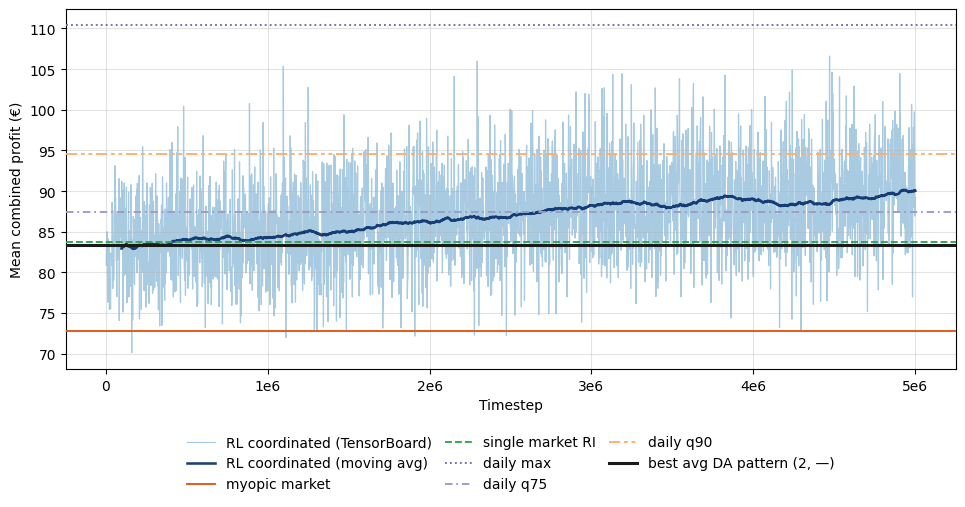

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

from evaluation.brute_force_summary_stats import (
    best_mean_profit_da_pattern_over_days,
    mean_profit_for_pattern_over_days,
)
from evaluation.rl_model_registry import rl_tensorboard_run_dir, rl_validation_summary_csv_path
from evaluation.tensorboard_rl_curves import EPISODE_PROFIT_COMBINED_TAG, load_tensorboard_scalar
from evaluation.training_period_baselines import (
    build_training_period_baselines_df,
    mean_reference_values_train_fit,
    mean_reference_values_validation_holdout,
)

# Seaborn default "colorblind" palette (Wong-style) — same hex as seaborn.color_palette("colorblind")
_SEABORN_COLORBLIND = (
    "#0173B2",
    "#DE8F05",
    "#029E73",
    "#D55E00",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#009E73",
)
_RL_BLUE = _SEABORN_COLORBLIND[0]

# Rolling mean over this many TensorBoard samples (rollout-end logs); larger = smoother
RL_TB_MOVING_AVG_WINDOW = 200
VALIDATION_RL_MA_WINDOW = 3

# Still returned by baselines helpers; omit from the figure (legend + lines)
SKIP_REF_KEYS = frozenset({"mean_brute_q075_eur"})

tb_dir = rl_tensorboard_run_dir(SELECTED_MODEL)
df_tb_train = load_tensorboard_scalar(tb_dir, EPISODE_PROFIT_COMBINED_TAG)

df_train_period = build_training_period_baselines_df(SELECTED_MODEL)
refs_train = mean_reference_values_train_fit(df_train_period)
refs_val = mean_reference_values_validation_holdout(df_train_period)

train_fit_days = df_train_period.loc[~df_train_period["is_validation_day"], "delivery_day"]
val_days = df_train_period.loc[df_train_period["is_validation_day"], "delivery_day"]

best_pattern_mean, best_pattern_info = best_mean_profit_da_pattern_over_days(train_fit_days)
pattern_mean_on_val = (
    mean_profit_for_pattern_over_days(best_pattern_info, val_days)
    if best_pattern_info and "buy_hour" in best_pattern_info
    else None
)

sum_path = rl_validation_summary_csv_path(SELECTED_MODEL)
df_val_sum = pd.read_csv(sum_path)
if "steps" not in df_val_sum.columns:
    raise ValueError(f"{sum_path}: expected column 'steps'")
y_col = "mean_profit" if "mean_profit" in df_val_sum.columns else "profit"
if y_col not in df_val_sum.columns:
    raise ValueError(f"{sum_path}: need 'mean_profit' or 'profit'")
df_val_sum = df_val_sum.sort_values("steps").reset_index(drop=True)
steps_v = df_val_sum["steps"].to_numpy(dtype=float)
y_v = df_val_sum[y_col].to_numpy(dtype=float)


def _hour_label(x) -> str:
    if not pd.notna(x):
        return "—"
    xf = float(x)
    if abs(xf - round(xf)) < 1e-6:
        return str(int(round(xf)))
    return f"{xf:g}"


def _best_pattern_legend_label(info: dict) -> str:
    """Thesis-style label with concrete DA hours (CSV convention 1…24)."""
    bh = _hour_label(info.get("buy_hour")) if info else "—"
    sh = _hour_label(info.get("sell_hour")) if info else "—"
    return f"best avg DA pattern ({bh}, {sh})"


_ref_labels = {
    "mean_myopic_eur": "myopic market",
    "mean_single_market_ri_eur": "single market RI",
    "mean_theoretical_max_eur": "daily max",
    "mean_brute_q090_eur": "daily q90",
}
_ref_colors = {
    "mean_myopic_eur": _SEABORN_COLORBLIND[1],
    "mean_single_market_ri_eur": _SEABORN_COLORBLIND[2],
    "mean_theoretical_max_eur": _SEABORN_COLORBLIND[3],
    "mean_brute_q090_eur": _SEABORN_COLORBLIND[4],
}
_ref_linestyle = {
    "mean_myopic_eur": "-",
    "mean_single_market_ri_eur": "--",
    "mean_theoretical_max_eur": ":",
    "mean_brute_q090_eur": (0, (6, 2, 2, 2, 2, 2)),
}


def _format_timestep_e6(x, _pos):
    if x == 0:
        return "0"
    return f"{x / 1e6:g}e6"


_ma_min_tb = max(3, RL_TB_MOVING_AVG_WINDOW // 4)
tb_ma = (
    df_tb_train["value"]
    .rolling(window=RL_TB_MOVING_AVG_WINDOW, min_periods=_ma_min_tb)
    .mean()
)

_ma_min_v = max(2, VALIDATION_RL_MA_WINDOW // 2)
y_ma = (
    pd.Series(y_v)
    .rolling(window=VALIDATION_RL_MA_WINDOW, min_periods=_ma_min_v)
    .mean()
    .to_numpy()
)

fig, (ax_tb, ax_v) = plt.subplots(1, 2, figsize=(11.0, 3.75), sharey=False)

ax_tb.plot(
    df_tb_train["step"],
    df_tb_train["value"],
    color=_RL_BLUE,
    lw=0.85,
    alpha=0.38,
    zorder=1,
    label="RL coordinated (TensorBoard)",
)
ax_tb.plot(
    df_tb_train["step"],
    tb_ma,
    color=_RL_BLUE,
    lw=1.55,
    alpha=0.92,
    zorder=2,
    label="RL coordinated (moving avg)",
)
for key, y in refs_train.items():
    if key in SKIP_REF_KEYS:
        continue
    ax_tb.axhline(
        y,
        color=_ref_colors.get(key, "#333333"),
        ls=_ref_linestyle.get(key, "--"),
        lw=1.15,
        zorder=3,
        label=_ref_labels.get(key, key),
    )
if best_pattern_mean is not None:
    ax_tb.axhline(
        best_pattern_mean,
        color="#1a1a1a",
        ls="-",
        lw=2.0,
        zorder=3,
        label=_best_pattern_legend_label(best_pattern_info),
    )
ax_tb.set_ylabel("Profit (€)")
ax_tb.set_xlabel("Timestep")
ax_tb.xaxis.set_major_locator(MultipleLocator(1e6))
ax_tb.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))
handles_tb, labels_tb = ax_tb.get_legend_handles_labels()
ax_tb.legend(
    handles_tb,
    labels_tb,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=8,
    frameon=False,
    columnspacing=0.75,
)

ax_v.plot(
    steps_v,
    y_v,
    "o",
    ms=3.2,
    alpha=0.45,
    color=_RL_BLUE,
    zorder=1,
)
ax_v.plot(
    steps_v,
    y_v,
    "-",
    lw=0.75,
    alpha=0.35,
    color=_RL_BLUE,
    zorder=1,
    label="RL coordinated (checkpoints)",
)
ax_v.plot(
    steps_v,
    y_ma,
    color=_RL_BLUE,
    lw=1.7,
    alpha=0.92,
    zorder=2,
    label="RL coordinated (moving avg)",
)
for key, y in refs_val.items():
    if key in SKIP_REF_KEYS:
        continue
    ax_v.axhline(
        y,
        color=_ref_colors.get(key, "#333333"),
        ls=_ref_linestyle.get(key, "--"),
        lw=1.15,
        zorder=3,
        label=_ref_labels.get(key, key),
    )
if pattern_mean_on_val is not None:
    ax_v.axhline(
        pattern_mean_on_val,
        color="#1a1a1a",
        ls="-",
        lw=2.0,
        zorder=3,
        label=_best_pattern_legend_label(best_pattern_info),
    )
ax_v.set_ylabel("Profit (€)")
ax_v.set_xlabel("Timestep")
ax_v.xaxis.set_major_locator(MultipleLocator(1e6))
ax_v.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))
handles_v, labels_v = ax_v.get_legend_handles_labels()
ax_v.legend(
    handles_v,
    labels_v,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=8,
    frameon=False,
    columnspacing=0.75,
)

for ax in (ax_tb, ax_v):
    ax.tick_params(axis="both", which="both", length=0)
    ax.grid(False)

fig.subplots_adjust(bottom=0.32, top=0.96, left=0.07, right=0.99, wspace=0.28)
plt.show()


**Training-period baselines table** (from the cell above): `df_train_period` = all days in the registry training window present in myopic `profit.csv`, merged with single-market RI + brute-force stats. Rows with `is_validation_day` are the random holdout; train-fit means use `~is_validation_day` (see `split_training_baselines_train_vs_validation` if you want two frames).


In [23]:
pd.Series(
    {
        "days_in_window": len(df_train_period),
        "train_fit_rows": int((~df_train_period["is_validation_day"]).sum()),
        "validation_holdout_rows": int(df_train_period["is_validation_day"].sum()),
    }
)


days_in_window             821
train_fit_rows             731
validation_holdout_rows     90
dtype: int64

In [24]:
df_train_period.describe()


,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit
count,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000
mean,72.248232,83.549996,110.033516,78.221191,87.160614,94.233431
std,48.278408,50.874585,72.614884,49.132672,53.999102,57.494476
min,5.288567,17.538780,31.143158,18.243006,21.173449,24.144998
25%,43.269497,53.637417,71.683721,48.621248,56.277188,60.856280
50%,62.289791,72.218219,93.199010,66.208687,74.404053,80.646380
75%,87.474255,100.922276,126.232376,92.220730,102.222086,109.754201
max,725.128381,773.818973,1156.318012,768.655032,875.015317,920.456346
